In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-27T15:09:27.274640+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn   : 0.13.2
pandas    : 2.2.3
numpy     : 2.1.2
marimo    : 0.23.2
requests  : 2.34.2
matplotlib: 3.10.7
teeplot   : 1.4.2

```

## Data

Load the per-replicate Hamming-weight time series produced by the
founder-sweep slurm job (`slurm/2026-05-20/2026-05-20-founder.sh`,
notebook `bindle/2026-05-20-founder.py`), cached as a parquet on
OSF. The sweep covers four `N_SITES` conditions
(`2, 3, 4, 5`) at 20 replicates each, 5000 steps per replicate,
POP_SIZE=100_000, on CPU (engine=numpy). The dataframe has one
row per `(replicate_uid, Step, hw)` with the per-step number of
cases (`n_cases`) at each Hamming weight, alongside the
simulation parameters as constant-valued columns.

The OSF slug is downloaded with `requests` and cached at
`/tmp/<slug>` so re-runs hit the local copy.

In [ ]:
# CLI args. Defaults pull the founder-sweep hw parquet that
# backs this notebook.
_args = mo.cli_args()
OSF_SLUG = str(_args.get("osf-slug") or "xzusj")
OSF_URL = str(
    _args.get("osf-url") or f"https://osf.io/{OSF_SLUG}/download",
)
print(f"args: OSF_SLUG={OSF_SLUG} OSF_URL={OSF_URL}")

args: OSF_SLUG=xzusj OSF_URL=https://osf.io/xzusj/download


In [ ]:
cache_path = pathlib.Path("/tmp") / OSF_SLUG
if not cache_path.exists():
    print(f"downloading {OSF_URL} -> {cache_path}")
    resp = requests.get(OSF_URL, allow_redirects=True, timeout=120)
    resp.raise_for_status()
    cache_path.write_bytes(resp.content)
else:
    print(f"reusing cached {cache_path}")
print(f"size: {cache_path.stat().st_size} bytes")

hw_df = pd.read_parquet(cache_path)
print(f"loaded hw dataframe: {hw_df.shape}")
print(
    "n_sites x replicate counts:\n"
    + str(hw_df.groupby("n_sites")["replicate_uid"].nunique()),
)

downloading https://osf.io/xzusj/download -> /tmp/xzusj
size: 6769145 bytes
loaded hw dataframe: (1800000, 20)
n_sites x replicate counts:
n_sites
2    20
3    20
4    20
5    20
Name: replicate_uid, dtype: int64


## Top-2 Convergence Hamming Weights

For each replicate, locate the run's last simulation step and
identify the **top two Hamming-weight bins** by case count
(`n_cases`) at that step. The Hamming-weight bin is used as a
coarse strain identifier --- with only the aggregated `hw`
dataframe in hand, each bin stands in for the set of genomes
sharing a given mutational distance from the founder
(all-zero wildtype) strain.

We then tabulate, separately for each `N_SITES` condition, the
**fraction of replicates** whose end-state top-two pair falls at
each `(hw_top1, hw_top2)` combination. Convergence to a single
Hamming weight shows up as mass on the `hw_top1 == hw_top2`
diagonal; divergent convergence to two distinct evolutionary
clusters shows up as off-diagonal mass.

In [ ]:
# Use the final step of each replicate (n_steps is constant within a
# replicate, but compute per-replicate to be safe).
last_steps = hw_df.groupby("replicate_uid")["Step"].transform("max")
last = hw_df[hw_df["Step"] == last_steps].copy()

def _top2(group):
    ranked = group.sort_values("n_cases", ascending=False)
    ranked = ranked[ranked["n_cases"] > 0]
    if len(ranked) == 0:
        return None
    top1_hw = int(ranked["hw"].iloc[0])
    # If only one Hamming-weight bin is occupied at end (rare given
    # extinction prevention guarantees at least one circulating
    # case, but the founder allele can be the sole survivor), fall
    # back to top1 so the pair stays well-defined.
    top2_hw = int(ranked["hw"].iloc[1]) if len(ranked) >= 2 else top1_hw
    return top1_hw, top2_hw

rows = []
for (_uid, _n_sites), _sub in last.groupby(
    ["replicate_uid", "n_sites"],
):
    _pair = _top2(_sub)
    if _pair is None:
        continue
    rows.append(
        {
            "replicate_uid": _uid,
            "n_sites": int(_n_sites),
            "hw_top1": _pair[0],
            "hw_top2": _pair[1],
        },
    )

top2_df = pd.DataFrame(rows)
print(f"top-2 frame: {top2_df.shape}")
print(
    "replicates per n_sites:\n" + str(top2_df.groupby("n_sites").size()),
)

top-2 frame: (80, 4)
replicates per n_sites:
n_sites
2    20
3    20
4    20
5    20
dtype: int64


In [ ]:
# Fraction of replicates per (n_sites, hw_top1, hw_top2) cell.
counts = (
    top2_df.groupby(["n_sites", "hw_top1", "hw_top2"])
    .size()
    .rename("n_reps")
    .reset_index()
)
totals = top2_df.groupby("n_sites").size().rename("n_total").reset_index()
frac_df = counts.merge(totals, on="n_sites")
frac_df["fraction"] = frac_df["n_reps"] / frac_df["n_total"]
print(frac_df.to_string(index=False))

 n_sites  hw_top1  hw_top2  n_reps  n_total  fraction
       2        0        2      12       20      0.60
       2        2        0       8       20      0.40
       3        1        2      11       20      0.55
       3        2        1       5       20      0.25
       3        3        0       4       20      0.20
       4        1        3       8       20      0.40
       4        2        1       5       20      0.25
       4        2        3       4       20      0.20
       4        3        1       3       20      0.15
       5        1        4       1       20      0.05
       5        2        3       5       20      0.25
       5        3        2      10       20      0.50
       5        4        1       4       20      0.20


## Fraction-of-Runs Heatmap

One panel per `N_SITES` condition. Axes are the top-two Hamming
weights at the final step (`hw_top1` = most-populous bin,
`hw_top2` = second-most). Cell color encodes the fraction of
replicates (out of 20) whose end state lands in that pair; cells
with no replicates are masked white. The fraction-as-text overlay
makes it easy to read off counts directly.

teeplots/2026-05-27-founder-top2-convergence/a=top2-hw-fraction+viz=subplots+ext=.pdf
teeplots/2026-05-27-founder-top2-convergence/a=top2-hw-fraction+viz=subplots+ext=.png


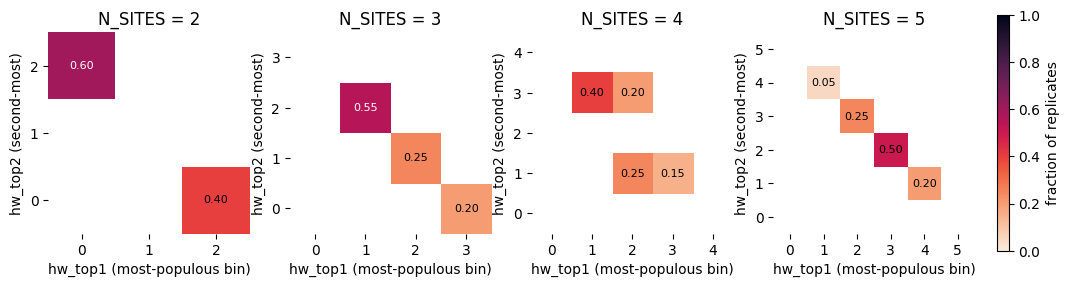

In [ ]:
n_sites_vals = sorted(frac_df["n_sites"].unique().tolist())
n_panels = len(n_sites_vals)

with tp.teed(
    plt.subplots,
    nrows=1,
    ncols=n_panels,
    figsize=(3.6 * n_panels, 3.6),
    squeeze=False,
    teeplot_outattrs={"a": "top2-hw-fraction"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (fig, axes):
    axes = axes[0]
    for _ax, _ns in zip(axes, n_sites_vals):
        _sub = frac_df[frac_df["n_sites"] == _ns]
        _hw_max = int(_ns)
        grid = np.full((_hw_max + 1, _hw_max + 1), np.nan)
        for _, _row in _sub.iterrows():
            grid[int(_row["hw_top2"]), int(_row["hw_top1"])] = float(
                _row["fraction"],
            )
        _masked = np.ma.masked_invalid(grid)
        _cmap = plt.get_cmap("rocket_r").copy()
        _cmap.set_bad("white")
        _im = _ax.imshow(
            _masked,
            origin="lower",
            cmap=_cmap,
            vmin=0.0,
            vmax=1.0,
            aspect="equal",
            interpolation="nearest",
        )
        for _i in range(_hw_max + 1):
            for _j in range(_hw_max + 1):
                if not np.ma.is_masked(_masked[_i, _j]):
                    _ax.text(
                        _j,
                        _i,
                        f"{_masked[_i, _j]:.2f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=(
                            "white" if _masked[_i, _j] > 0.5 else "black"
                        ),
                    )
        _ax.set_xticks(range(_hw_max + 1))
        _ax.set_yticks(range(_hw_max + 1))
        _ax.set_xlabel("hw_top1 (most-populous bin)")
        _ax.set_ylabel("hw_top2 (second-most)")
        _ax.set_title(f"N_SITES = {_ns}")
        sns.despine(ax=_ax, left=True, bottom=True)
    cbar = fig.colorbar(
        _im,
        ax=axes,
        pad=0.02,
        shrink=0.85,
        label="fraction of replicates",
    )
    _ = cbar